## Text EDA and Baseline NLP
### ADS-509 Final Project

### Imports

In [1]:
# ================================
# Core
# ================================
import pandas as pd
import numpy as np
import re

# ================================
# Visualization
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting style
sns.set_style("whitegrid")

# ================================
# NLP / Feature Extraction
# ================================
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# ================================
# Word Cloud
# ================================
from wordcloud import WordCloud

In [2]:
import os
print(os.getcwd())

/Users/Jordan/Documents/USD/Spring 2026/ADS 509/Final Project/notebooks


In [3]:
from pathlib import Path

# -------------------------
# Load canonical dataset (from Notebook 01 output)
# -------------------------
PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_PATH = DATA_PROCESSED / "jobs_combined.csv"

assert DATA_PATH.exists(), f"Missing file: {DATA_PATH}. Run Notebook 01 first."
df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
print(df["source"].value_counts(dropna=False))

# -------------------------
# Choose ONE analysis text column (consistent everywhere)
# Prefer description (cleaned), fall back to text
# -------------------------
TEXT_COL = "description" if "description" in df.columns else "text"
df[TEXT_COL] = (
    df[TEXT_COL]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["text_len"] = df[TEXT_COL].str.len()

# Split by source (keeps everything reproducible)
indeed = df[df["source"].str.lower() == "indeed"].copy()
linkedin = df[df["source"].str.lower() == "linkedin"].copy()

# Convenience series used throughout the notebook
indeed_text = indeed[TEXT_COL].fillna("")
linkedin_text = linkedin[TEXT_COL].fillna("")

print("Indeed:", indeed.shape)
print("LinkedIn:", linkedin.shape)
print("Empty text rate:", (df[TEXT_COL].str.len() == 0).mean())

Loaded: /Users/Jordan/Documents/USD/Spring 2026/ADS 509/Final Project/data/processed/jobs_combined.csv
Shape: (200, 10)
source
indeed      100
linkedin    100
Name: count, dtype: int64

TEXT_COL = text
Indeed: (100, 11)
LinkedIn: (100, 11)
Empty text rate: 0.0


In [4]:
# Inspect Columns
print("Indeed Columns:")
print(indeed.columns)

print("\nLinkedIn Columns:")
print(linkedin.columns)


Indeed Columns:
Index(['source', 'search_term', 'title', 'company', 'location', 'date_posted',
       'job_type', 'description', 'job_url', 'text', 'text_len'],
      dtype='object')

LinkedIn Columns:
Index(['source', 'search_term', 'title', 'company', 'location', 'date_posted',
       'job_type', 'description', 'job_url', 'text', 'text_len'],
      dtype='object')


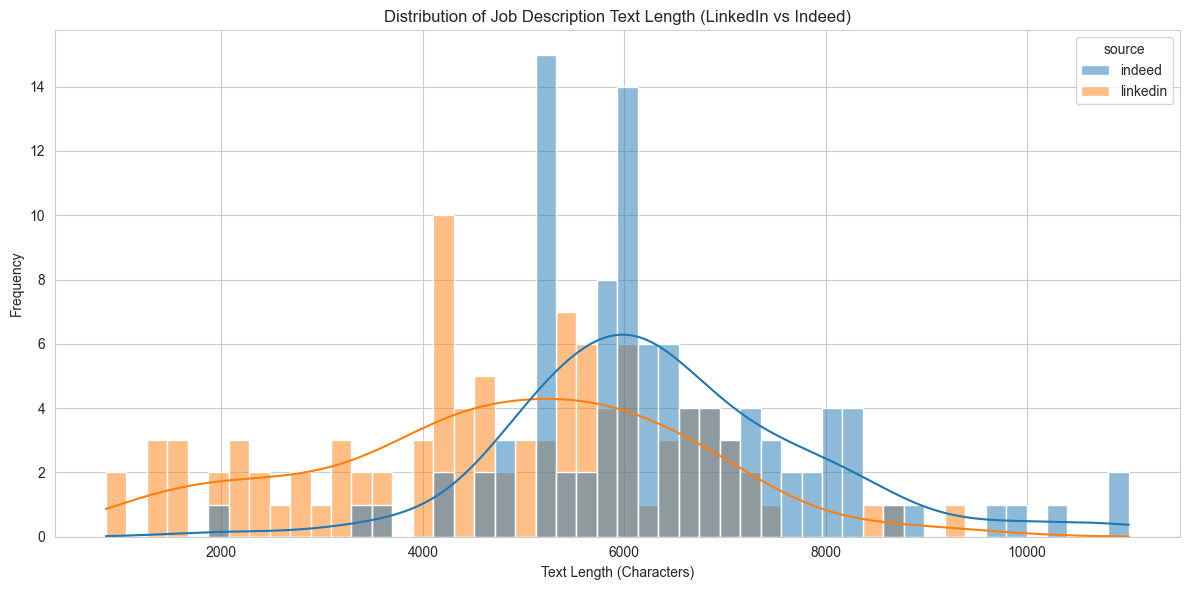

In [13]:
# Text length distribution (LinkedIn vs Indeed)

plt.figure(figsize=(12,6))
sns.histplot(data=df, x="text_len", hue="source", bins=50, kde=True)
plt.title("Distribution of Job Description Text Length (LinkedIn vs Indeed)")
plt.xlabel("Text Length (Characters)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

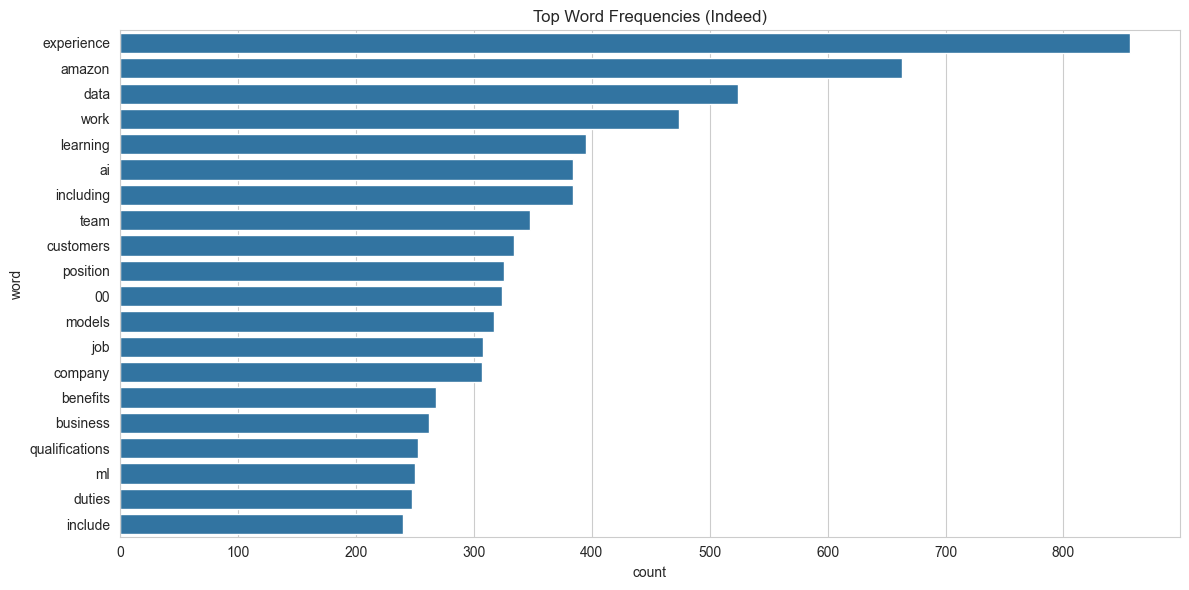

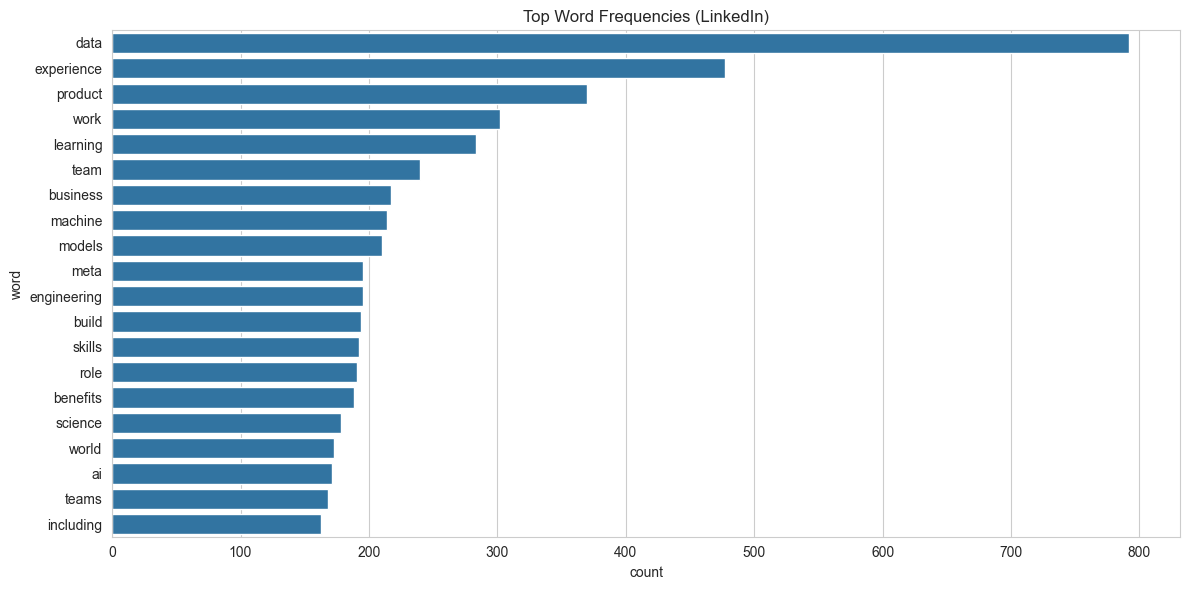

In [6]:
# Word Frequencies
def top_word_counts(text_series, max_features=20):
    vec = CountVectorizer(stop_words="english", max_features=max_features)
    X = vec.fit_transform(text_series)
    counts = pd.DataFrame({
        "word": vec.get_feature_names_out(),
        "count": X.sum(axis=0).A1
    }).sort_values("count", ascending=False)
    return counts

indeed_word_counts = top_word_counts(indeed_text, max_features=20)
linkedin_word_counts = top_word_counts(linkedin_text, max_features=20)

# Plot side by side as two charts (simple + readable)
plt.figure(figsize=(12, 6))
sns.barplot(data=indeed_word_counts, x="count", y="word")
plt.title("Top Word Frequencies (Indeed)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=linkedin_word_counts, x="count", y="word")
plt.title("Top Word Frequencies (LinkedIn)")
plt.tight_layout()
plt.show()

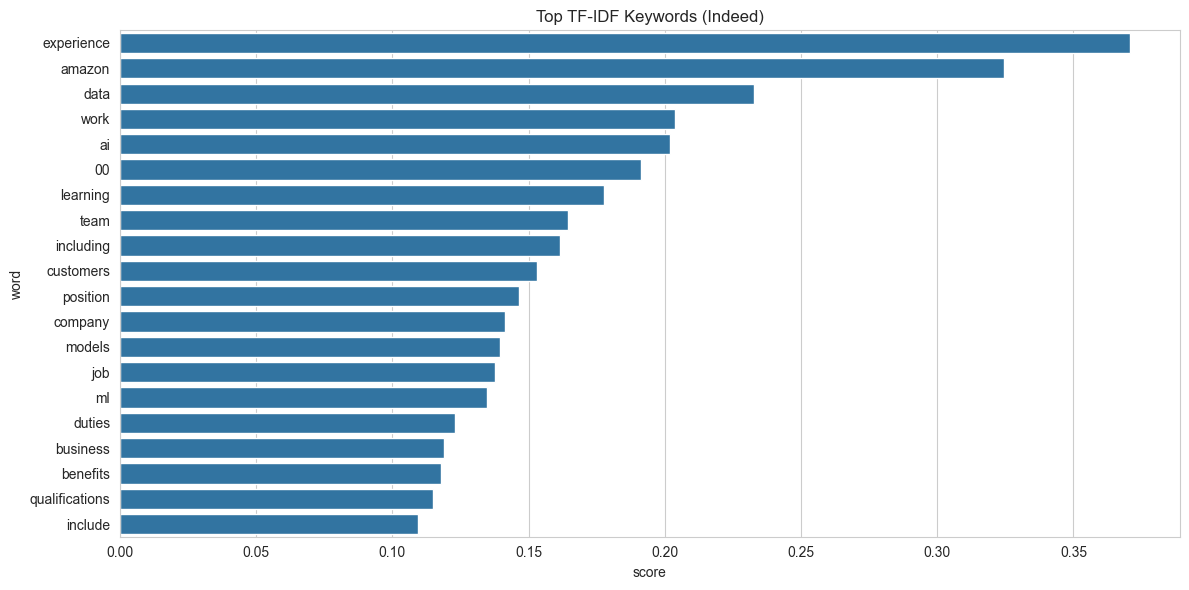

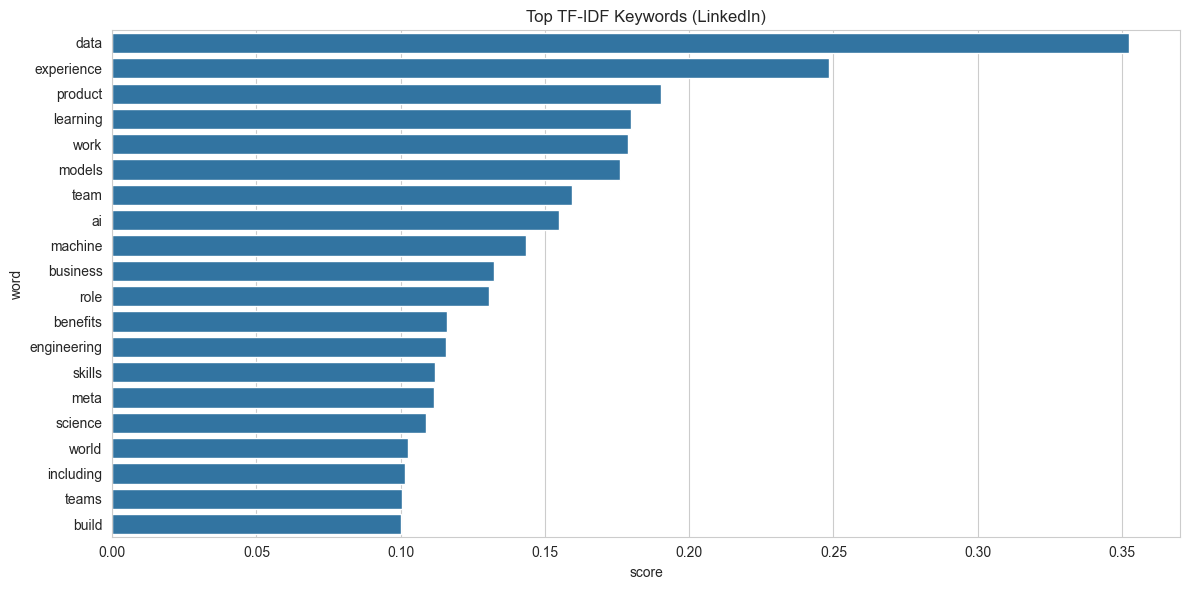

In [7]:
# TF-IDF Keywords
def top_tfidf_terms(text_series, max_features=20):
    tfidf = TfidfVectorizer(stop_words="english", max_features=max_features)
    X = tfidf.fit_transform(text_series)
    scores = pd.DataFrame({
        "word": tfidf.get_feature_names_out(),
        "score": np.asarray(X.mean(axis=0)).ravel()
    }).sort_values("score", ascending=False)
    return scores

indeed_tfidf = top_tfidf_terms(indeed_text, max_features=20)
linkedin_tfidf = top_tfidf_terms(linkedin_text, max_features=20)

plt.figure(figsize=(12, 6))
sns.barplot(data=indeed_tfidf, x="score", y="word")
plt.title("Top TF-IDF Keywords (Indeed)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=linkedin_tfidf, x="score", y="word")
plt.title("Top TF-IDF Keywords (LinkedIn)")
plt.tight_layout()
plt.show()

#### Most Mentioned Skills

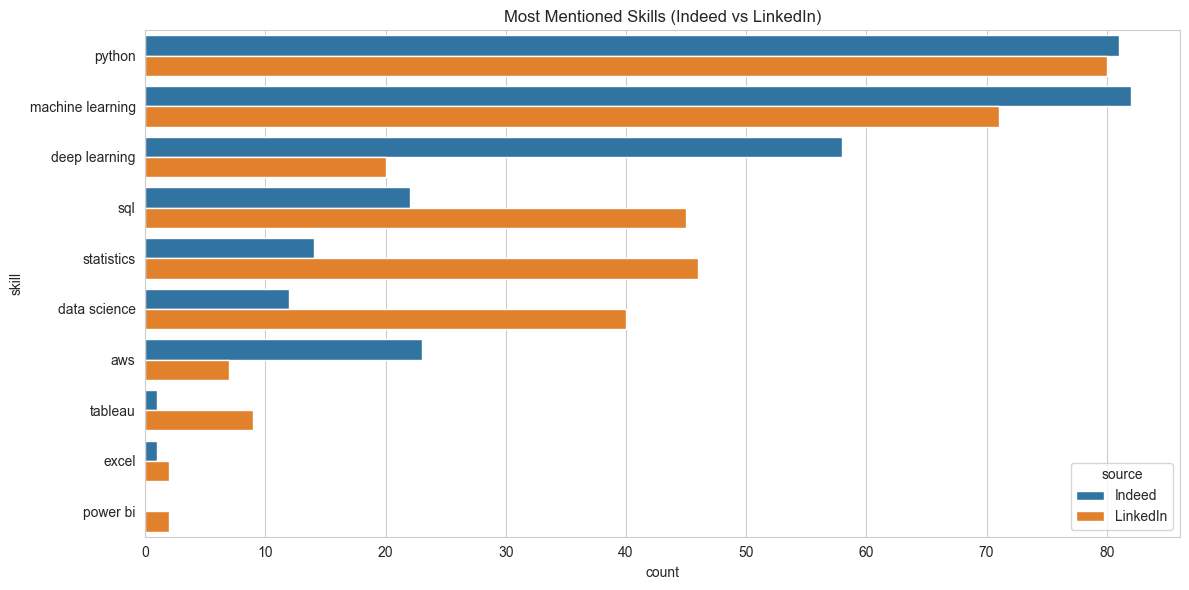

In [8]:
skills = [
    "python", "sql", "machine learning", "aws",
    "excel", "tableau", "power bi", "data science",
    "deep learning", "statistics"
]

def count_skill_mentions(text_series, skill_list):
    counts = {}
    for s in skill_list:
        pattern = r"\b" + re.escape(s.lower()) + r"\b"
        counts[s] = text_series.str.lower().str.contains(pattern, regex=True, na=False).sum()
    return pd.Series(counts).sort_values(ascending=False)

indeed_skill_counts = count_skill_mentions(indeed_text, skills)
linkedin_skill_counts = count_skill_mentions(linkedin_text, skills)

compare_skills = pd.DataFrame({
    "Indeed": indeed_skill_counts,
    "LinkedIn": linkedin_skill_counts
}).fillna(0).astype(int)

# Plot top 10 by combined count
compare_skills["Total"] = compare_skills["Indeed"] + compare_skills["LinkedIn"]
top_skills = compare_skills.sort_values("Total", ascending=False).head(10).drop(columns="Total")

plot_df = top_skills.reset_index(names="skill").melt(id_vars="skill", var_name="source", value_name="count")

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x="count", y="skill", hue="source")
plt.title("Most Mentioned Skills (Indeed vs LinkedIn)")
plt.tight_layout()
plt.show()


#### World Cloud

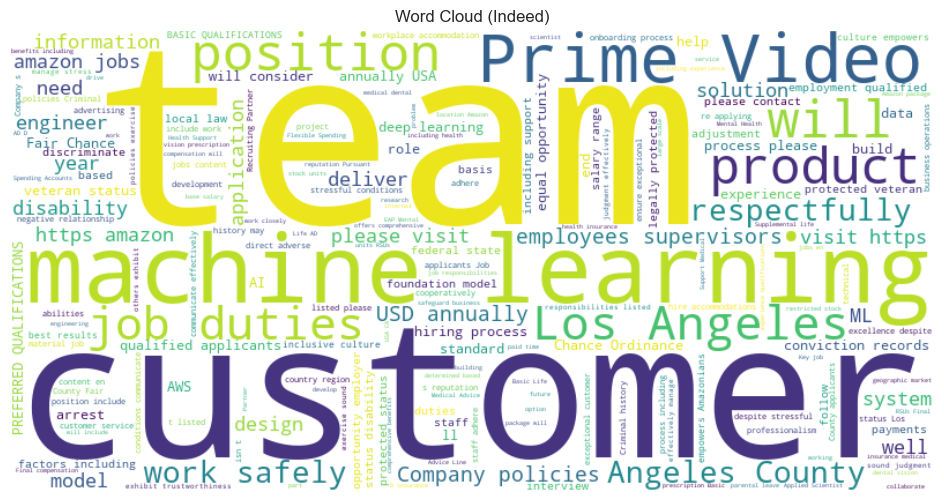

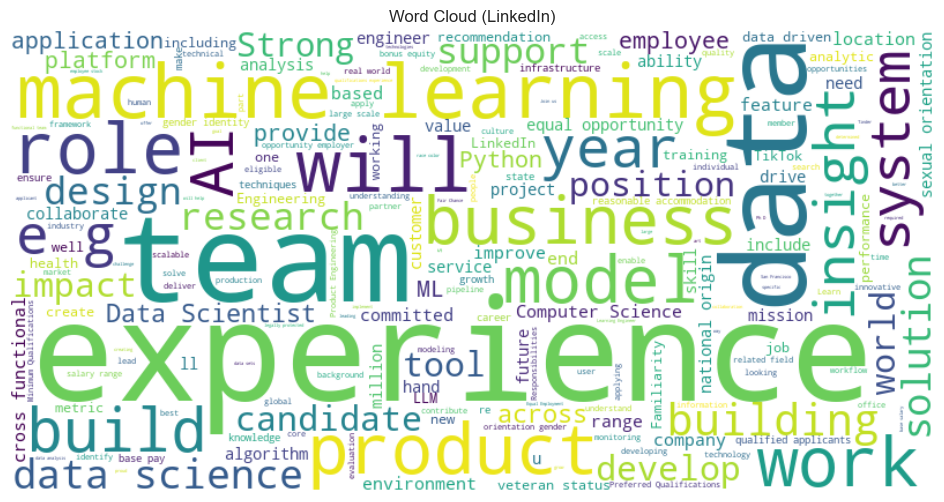

In [9]:
def make_wordcloud(text_series, title):
    all_text = " ".join(text_series.astype(str).tolist())
    wc = WordCloud(width=800, height=400, background_color="white").generate(all_text)
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

make_wordcloud(indeed_text, "Word Cloud (Indeed)")
make_wordcloud(linkedin_text, "Word Cloud (LinkedIn)")

# Baseline NLP: Text Preprocessing

In [10]:
def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"[^\w\s]", " ", s)   # punctuation -> space
    s = re.sub(r"\d+", " ", s)       # remove numbers
    s = re.sub(r"\s+", " ", s).strip()
    return s

indeed["clean_text"] = indeed[TEXT_COL].apply(clean_text)
linkedin["clean_text"] = linkedin[TEXT_COL].apply(clean_text)

#### Baseline NLP: TF-IDF Keyword Extraction

In [11]:
def tfidf_keywords(clean_series, max_features=25):
    tfidf = TfidfVectorizer(stop_words="english", max_features=max_features)
    X = tfidf.fit_transform(clean_series)
    out = pd.DataFrame({
        "keyword": tfidf.get_feature_names_out(),
        "score": np.asarray(X.mean(axis=0)).ravel()
    }).sort_values("score", ascending=False)
    return out

indeed_clean = indeed["clean_text"].dropna()
linkedin_clean = linkedin["clean_text"].dropna()

indeed_tfidf_clean = tfidf_keywords(indeed_clean, max_features=25)
linkedin_tfidf_clean = tfidf_keywords(linkedin_clean, max_features=25)

indeed_tfidf_clean.head(10), linkedin_tfidf_clean.head(10)

(       keyword     score
 8   experience  0.312124
 1       amazon  0.290786
 6         data  0.224082
 0           ai  0.199452
 24        work  0.177195
 12    learning  0.152643
 22        team  0.148516
 10   including  0.141286
 18       prime  0.139784
 15          ml  0.127090,
        keyword     score
 5         data  0.346009
 7   experience  0.212240
 15     product  0.178956
 9     learning  0.162871
 23        work  0.161263
 12      models  0.152031
 0           ai  0.149752
 20        team  0.140977
 10     machine  0.130067
 4     business  0.122302)

#### Baseline NLP: Bigram Analysis

In [12]:
def top_bigrams(clean_series, max_features=20):
    vec = CountVectorizer(stop_words="english", ngram_range=(2,2), max_features=max_features)
    X = vec.fit_transform(clean_series)
    out = pd.DataFrame({
        "bigram": vec.get_feature_names_out(),
        "count": X.sum(axis=0).A1
    }).sort_values("count", ascending=False)
    return out

indeed_bigrams = top_bigrams(indeed_clean, max_features=20)
linkedin_bigrams = top_bigrams(linkedin_clean, max_features=20)

indeed_bigrams.head(10), linkedin_bigrams.head(10)

(                   bigram  count
 14            prime video    219
 12       machine learning    215
 10             job duties    159
 11            los angeles    159
 1          angeles county    158
 16      supervisors staff    156
 13       position include    156
 19            work safely    156
 7   employees supervisors    156
 6         duties position    156,
                 bigram  count
 11    machine learning    244
 7       data scientist    108
 6         data science    103
 2     computer science     69
 3     cross functional     65
 8    equal opportunity     62
 10   learning engineer     56
 18  sexual orientation     55
 12     national origin     55
 19      veteran status     53)

Baseline NLP: Skills and Tools Mention Analysis

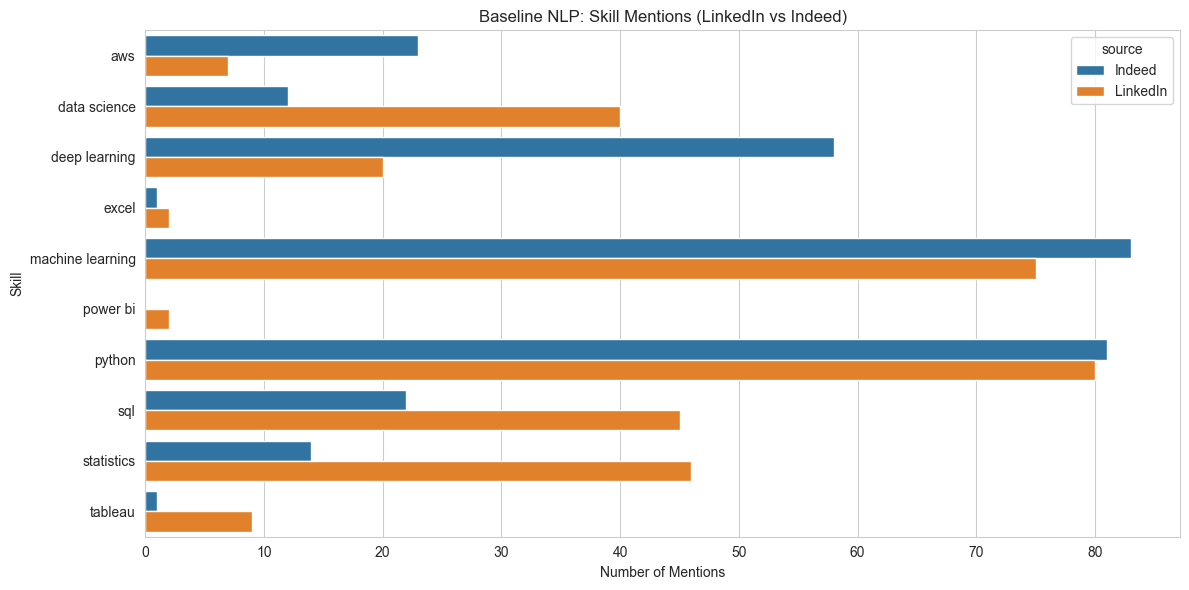

In [14]:
skills = [
    "python", "sql", "machine learning", "aws",
    "excel", "tableau", "power bi", "data science",
    "deep learning", "statistics"
]

def count_skill_mentions(text_series, skill_list):
    counts = {}
    for s in skill_list:
        pattern = r"\b" + re.escape(s.lower()) + r"\b"
        counts[s] = text_series.str.lower().str.contains(pattern, regex=True, na=False).sum()
    return pd.Series(counts).sort_values(ascending=False)

indeed_skill_counts = count_skill_mentions(indeed[TEXT_COL], skills)
linkedin_skill_counts = count_skill_mentions(linkedin[TEXT_COL], skills)

compare_skills = pd.DataFrame({
    "Indeed": indeed_skill_counts,
    "LinkedIn": linkedin_skill_counts
}).fillna(0)

plot_df = compare_skills.reset_index().melt(id_vars="index", var_name="source", value_name="count")
plot_df.rename(columns={"index": "skill"}, inplace=True)

plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="count", y="skill", hue="source")
plt.title("Baseline NLP: Skill Mentions (LinkedIn vs Indeed)")
plt.xlabel("Number of Mentions")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

#### Baseline NLP Summary

A baseline NLP analysis was conducted using traditional text mining methods, including word frequency analysis and TF-IDF keyword extraction on the job description text. The results show that terms such as “data,” “AI,” “learning,” and “experience” appear frequently, indicating a strong emphasis on technical and data-related roles within the dataset. These interpretable, non-LLM methods establish a foundational benchmark that can later be compared against more advanced generative AI extraction methods.

